In [1]:
%pip install torchtext torchdata

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#the imports 
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.datasets import multi30k, Multi30k
from typing import Iterable, List
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from torchdata.datapipes.iter import IterableWrapper, Mapper
import torchtext
from torchtext.vocab import build_vocab_from_iterator
from nltk.translate.bleu_score import sentence_bleu
import torch
import torch.nn as nn
import torch.optim as optim

import gradio as gr

import numpy as np
import random
import math
import time
from tqdm import tqdm
import matplotlib.pyplot as plt


# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c

In [3]:
class Encoder(nn.Module):
    def __init__(self, vocab_len, emb_dim, hid_dim, n_layers, dropout_prob):
        super().__init__()
        self.hid_dim=hid_dim
        self.n_layers=n_layers
        self.embedding= nn.Embedding(vocab_len, emb_dim)
        self.lstm=nn.LSTM(emb_dim, hid_dim, n_layers, dropout = dropout_prob)
        self.dropout=nn.Dropout(dropout_prob)
    def forward(self,input_batch):
        embed=self.dropout(self.embedding(input_batch)) #transform the batch that contains the numero of words into embedding vectors and then apply the dropout to avoid the overfitting 
        embed=embed.to(device)
        outputs,(hidden,cell)=self.lstm(embed)
        return hidden ,cell 

In [4]:
#test du code :
vocab_len = 8
emb_dim = 10
hid_dim=8
n_layers=1
dropout_prob=0.5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder_t = Encoder(vocab_len, emb_dim, hid_dim, n_layers, dropout_prob).to(device)
print(encoder_t)

Encoder(
  (embedding): Embedding(8, 10)
  (lstm): LSTM(10, 8, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [5]:
src_batch = torch.tensor([[0,3,4,2,1]]) #the shape of this vector is [1,5] a sentence of 5 words but the Lstm prefers this input [ number of words ,number of sentences(length of batch)]
#  transpose the input tensor as the encoder LSTM is in Sequence_first mode by default
src_batch = src_batch.t().to(device)
print("Shape of input(src) tensor:", src_batch.shape)
hidden_t , cell_t = encoder_t(src_batch)
print("Hidden tensor from encoder:",hidden_t ,"\nCell tensor from encoder:", cell_t)

Shape of input(src) tensor: torch.Size([5, 1])
Hidden tensor from encoder: tensor([[[ 0.1748, -0.0473,  0.0998,  0.1722,  0.0969, -0.2453, -0.1361,
           0.2685]]], grad_fn=<StackBackward0>) 
Cell tensor from encoder: tensor([[[ 1.1149, -0.2458,  0.2292,  0.2437,  0.1327, -0.3527, -0.6680,
           0.5242]]], grad_fn=<StackBackward0>)


In [6]:
class Decoder(nn.Module):
    def __init__(self,output_dim,emb_dim,hid_dim,n_layers,dropout):
        super().__init__() 
        self.hid_dim=hid_dim 
        self.output_dim=output_dim 
        self.embedding=nn.Embedding(output_dim,emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, n_layers, dropout = dropout)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(dropout)
        self.n_layers = n_layers
    def forward(self,input,hidden,cell):
        input = input.unsqueeze(0) # the LSTM still expects a "Sequence Length" at the start so the unsequeeze add 1 
        #before :[batch_size]---- after :input = [1, batch size]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]
        embedded = self.dropout(self.embedding(input)) #embedded = [1, batch size, emb dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction_logit = self.fc_out(output.squeeze(0))
        prediction = self.softmax(prediction_logit)
        #prediction = [batch size, output dim]
        #batch size number of different sentences
        return prediction, hidden, cell

        

In [7]:
#decoder test 
output_dim = 6
emb_dim=256
hid_dim = 8
n_layers=1
dropout=0.5
decoder_t = Decoder(output_dim, emb_dim, hid_dim, n_layers, dropout).to(device)

In [8]:
input_t = torch.tensor([0]).to(device) #<bos>
input_t.shape
prediction, hidden, cell = decoder_t(input_t, hidden_t , cell_t)
print("Prediction:", prediction, '\nHidden:',hidden,'\nCell:', cell)

Prediction: tensor([[-2.0940, -1.9736, -1.4146, -1.6270, -1.8475, -1.9611]],
       grad_fn=<LogSoftmaxBackward0>) 
Hidden: tensor([[[-0.0382, -0.0016, -0.0486,  0.6895, -0.0048, -0.4437,  0.1754,
           0.5229]]], grad_fn=<StackBackward0>) 
Cell: tensor([[[-0.0803, -0.2603, -0.0767,  0.8488, -0.0106, -0.4852,  0.1999,
           1.4936]]], grad_fn=<StackBackward0>)


In [9]:
#Encoder-Decoder Connection manually :
#teacher_forcing_ratio is probability to use teacher forcing 
teacher_forcing_ratio = 0.5
trg = torch.tensor([[0],[2],[3],[5],[1]]).to(device) # 0 means start 1 means end , the tensore represents the target sentence 
#trg = [trg len, batch size]
batch_size = trg.shape[1]
trg_len = trg.shape[0]
trg_vocab_size = decoder_t.output_dim
#tensor to store decoder outputs
outputs_t = torch.zeros(trg_len, batch_size, trg_vocab_size).to(device) #an output initially contains zeros 
#send to device
hidden_t = hidden_t.to(device)
cell_t = cell_t.to(device)
input = trg[0,:]
for t in range(1, trg_len):

    #you loop through the trg len and generate tokens
    #decoder receives previous generated token, cell and hidden
    # decoder outputs it prediction(probablity distribution for the next token) and updates hidden and cell
    output_t, hidden_t, cell_t = decoder_t(input, hidden_t, cell_t)

    #place predictions in a tensor holding predictions for each token
    outputs_t[t] = output_t

    # Select either the ground truth (teacher forcing) or the model's prediction as the next input based on the probability ratio.
    teacher_force = random.random() < teacher_forcing_ratio

    #get the highest predicted token from your predictions
    top1 = output_t.argmax(1)


    #if teacher forcing, use actual next token as next input
    #if not, use predicted token
    #input = trg[t] if teacher_force else top1
    input = trg[t] if teacher_force else top1

print(outputs_t,outputs_t.shape )


tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]],

        [[-2.2387, -1.8063, -1.6645, -1.4456, -1.6855, -2.1294]],

        [[-1.6477, -1.9480, -1.5518, -1.7443, -1.8056, -2.1720]],

        [[-1.6487, -1.6978, -1.7670, -1.8497, -1.7520, -2.0952]],

        [[-1.5808, -1.9129, -1.6582, -1.8766, -2.0279, -1.7643]]],
       grad_fn=<CopySlices>) torch.Size([5, 1, 6])


In [10]:
#seq2seq class Encoder -> Context -> Decoder -> Loop
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device,trg_vocab):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.trg_vocab = trg_vocab

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):
        #src = [src len, batch size]
        #trg = [trg len, batch size]
        #teacher_forcing_ratio is probability to use teacher forcing
        #e.g. if teacher_forcing_ratio is 0.75 you use ground-truth inputs 75% of the time


        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        #tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        #last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)
        hidden = hidden.to(device)
        cell = cell.to(device)


        #first input to the decoder is the <bos> tokens
        input = trg[0,:]

        for t in range(1, trg_len):

            #insert input token embedding, previous hidden and previous cell states
            #receive output tensor (predictions) and new hidden and cell states
            output, hidden, cell = self.decoder(input, hidden, cell)

            #place predictions in a tensor holding predictions for each token
            outputs[t] = output

            #decide if you are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            #get the highest predicted token from your predictions
            top1 = output.argmax(1)


            #if teacher forcing, use actual next token as next input
            #if not, use predicted token
            #input = trg[t] if teacher_force else top1
            input = trg[t] if teacher_force else top1


        return outputs

In [11]:
def train(model, iterator, optimizer, criterion, clip):

    model.train()

    epoch_loss = 0

    # Wrap iterator with tqdm for progress logging
    train_iterator = tqdm(iterator, desc="Training", leave=False)

    for i, (src,trg) in enumerate(iterator):

        src = src.to(device)#src len number of words and batch size number of sentences 
        trg = trg.to(device)
        optimizer.zero_grad() #reset gradient each time otherwise they will be accumulated

        output = model(src, trg)

        #trg = [trg len, batch size]
        #output = [trg len, batch size, output dim]

        output_dim = output.shape[-1] #gives the vocabulary size 

        output = output[1:].view(-1, output_dim) #remoove first token which is usually <SOS> and we dont calculate loss on  it

        trg = trg[1:].contiguous().view(-1) #flatten into :[number of predictions ,vocab size ] because the cross entropy exects this

        #trg = [(trg len - 1) * batch size]
        #output = [(trg len - 1) * batch size, output dim]

        loss = criterion(output, trg) #CrossEntropy does:For each word:predicted probabilities compare correct word Then average loss.

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip) #very important because sequence models easily explode.

        optimizer.step() #Optimizer uses gradients to update weights 
        # Update tqdm progress bar with the current loss
        train_iterator.set_postfix(loss=loss.item())

        epoch_loss += loss.item()


    return epoch_loss / len(list(iterator))

In [12]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    # Wrap iterator with tqdm for progress logging
    valid_iterator = tqdm(iterator, desc="Training", leave=False)

    with torch.no_grad():

        for i, (src,trg) in enumerate(iterator):

            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, 0) #turn off teacher forcing
            # teacher forcing is turned off during evaluation to evaluate the model's ability to generate sequences based on its own predictions.

            #trg = [trg len, batch size]
            #output = [trg len, batch size, output dim]

            output_dim = output.shape[-1]

            output = output[1:].view(-1, output_dim)

            trg = trg[1:].contiguous().view(-1)


            #trg = [(trg len - 1) * batch size]
            #output = [(trg len - 1) * batch size, output dim]

            loss = criterion(output, trg)
            # Update tqdm progress bar with the current loss
            valid_iterator.set_postfix(loss=loss.item())

            epoch_loss += loss.item()

    return epoch_loss / len(list(iterator))

In [13]:
import urllib.request
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0205EN-SkillsNetwork/Multi30K_de_en_dataloader.py'
urllib.request.urlretrieve(url, 'Multi30K_de_en_dataloader.py')
print("File downloaded successfully!")

File downloaded successfully!


In [14]:
# 1. Install spacy
%pip install spacy

# 2. Download the German language model 
!python -m spacy download de_core_news_sm

# 3. Download the English language model 
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 187, in _run_module_as_main
    mod_name, mod_spec, code = _get_module_details(mod_name, _Error)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 146, in _get_module_details
    return _get_module_details(pkg_main_name, error)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 110, in _get_module_details
    __import__(pkg_name)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\spacy\__init__.py", line 6, in <module>
    from .e


     ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
     -- ------------------------------------- 0.8/14.6 MB 6.7 MB/s eta 0:00:03
     ------- -------------------------------- 2.6/14.6 MB 8.0 MB/s eta 0:00:02
     ----------- ---------------------------- 4.2/14.6 MB 8.7 MB/s eta 0:00:02
     --------------- ------------------------ 5.8/14.6 MB 7.7 MB/s eta 0:00:02
     ------------------ --------------------- 6.8/14.6 MB 7.4 MB/s eta 0:00:02
     ---------------------- ----------------- 8.1/14.6 MB 7.2 MB/s eta 0:00:01
     ------------------------- -------------- 9.4/14.6 MB 7.0 MB/s eta 0:00:01
     ------------------------------ --------- 11.0/14.6 MB 6.8 MB/s eta 0:00:01
     -------------------------------- ------- 12.1/14.6 MB 6.9 MB/s eta 0:00:01
     ------------------------------------ --- 13.4/14.6 MB 6.7 MB/s eta 0:00:01
     ---------------------------------------  14.4/14.6 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------- 14.6/14.


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 187, in _run_module_as_main
    mod_name, mod_spec, code = _get_module_details(mod_name, _Error)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 146, in _get_module_details
    return _get_module_details(pkg_main_name, error)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\runpy.py", line 110, in _get_module_details
    __import__(pkg_name)
  File "c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\spacy\__init__.py", line 6, in <module>
    from .e

In [15]:
%pip install portalocker>=2.0.0

Note: you may need to restart the kernel to use updated packages.


In [16]:
%run Multi30K_de_en_dataloader.py

In [27]:
train_dataloader, valid_dataloader = get_translation_dataloaders(batch_size = 128)

In [28]:
src, trg = next(iter(train_dataloader))
src,trg

(tensor([[   2,    2,    2,  ...,    2,    2,    2],
         [   3, 5510, 5510,  ...,   14,    5,  271],
         [   1,    3,    3,  ...,   38,  232,  447],
         ...,
         [   1,    1,    1,  ...,    4,    4,    4],
         [   1,    1,    1,  ...,    3,    3,    3],
         [   1,    1,    1,  ...,    1,    1,    1]]),
 tensor([[   2,    2,    2,  ...,    2,    2,    2],
         [   3, 6650,  216,  ...,    6,    6,  381],
         [   1, 4623,  110,  ...,   39,  341,  463],
         ...,
         [   1,    3,    3,  ...,    1,    1,    3],
         [   1,    1,    1,  ...,    1,    1,    1],
         [   1,    1,    1,  ...,    1,    1,    1]]))

In [33]:
data_itr = iter(train_dataloader)
# sentences are sorted by length in the data 
# moving forward in the dataset to reach sequences of longer length for illustration purpose. (Remember the dataset is sorted on sequence len for optimal padding)
for n in range(30):
    german, english= next(data_itr)

for n in range(3):
    german, english=next(data_itr)
    german=german.T
    english=english.T
    print("________________")
    print("german")
    for g in german:
        print(index_to_german(g)) #converts numbers back into human words 
    print("________________")
    print("english")
    for e in english:
        print(index_to_eng(e)) #converts numbers back into human words 


________________
german
<bos> Zwei Kinder umarmen sich auf einer Schaukel . <eos> <pad>
<bos> Ein Mann schläft auf einer roten Bank . <eos> <pad>
<bos> Eine Frau verteilt Flyer an vorbeigehende Personen . <eos> <pad>
<bos> Ein uniformierter Mann steht an einem Eingang . <eos> <pad>
<bos> Eine Person wandert am Fuß schneebedeckter Berge . <eos> <pad>
<bos> Eine Menschengruppe posiert zusammen für ein Foto . <eos> <pad>
<bos> Zwei Männer trinken vor einem Zaun Bier . <eos> <pad>
<bos> Mehrere Personen stehen am Bahnsteig einer U-Bahn . <eos> <pad>
<bos> Ein Klassenzimmer voller Kinder an blauen Tischen . <eos> <pad>
<bos> Ein Mann macht vor Zuschauern einen Salto . <eos> <pad>
<bos> Mehrere Personen gehen , sitzen oder fahren Rad . <eos>
<bos> An einer großen Kathedrale werden Bauarbeiten durchgeführt . <eos> <pad>
<bos> Zwei Kerle machen auf einer Matte Karate . <eos> <pad>
<bos> Ein Mann mit brauner Hose fährt Rollerblades . <eos> <pad>
<bos> Drei Freunde im Park auf dem Gras . <eos> <

In [34]:
#This code sets the random seed for various libraries and modules in order to make the results reproducible:
import random
import numpy as np
import torch

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [35]:
INPUT_DIM = len(vocab_transform['de'])
OUTPUT_DIM = len(vocab_transform['en'])
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256 
HID_DIM = 256
N_LAYERS = 2
ENC_DROPOUT = 0.3 
DEC_DROPOUT = 0.3 
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device,trg_vocab = vocab_transform['en']).to(device)

In [36]:
#initializing the weights of the neural networks 
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(19214, 256)
    (lstm): LSTM(256, 256, num_layers=2, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10837, 256)
    (lstm): LSTM(256, 256, num_layers=2, dropout=0.3)
    (fc_out): Linear(in_features=256, out_features=10837, bias=True)
    (softmax): LogSoftmax(dim=1)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (trg_vocab): Vocab()
)

In [37]:
# counts every single individual weight (number) that the model will be trying to learn and update during training.
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 12,583,509 trainable parameters


In [38]:
optimizer = optim.Adam(model.parameters(),lr=0.001)

PAD_IDX = vocab_transform['en'].get_stoi()['<pad>']  #retrieves the index of the `<pad>` token in the target vocabulary.
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX)

In [39]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
torch.cuda.empty_cache()

N_EPOCHS = 15 #n the training for at least 5 epochs
CLIP = 1

best_valid_loss = float('inf')
best_train_loss = float('inf')
train_losses = []
valid_losses = []

train_PPLs = []
valid_PPLs = []

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP)
    train_ppl = math.exp(train_loss)
    valid_loss = evaluate(model, valid_dataloader, criterion)
    valid_ppl = math.exp(valid_loss)


    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)


    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'RNN-TR-model.pt')

    train_losses.append(train_loss)
    train_PPLs.append(train_ppl)
    valid_losses.append(valid_loss)
    valid_PPLs.append(valid_ppl)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {train_ppl:7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {valid_ppl:7.3f}')


Epoch: 01 | Time: 12m 47s
	Train Loss: 5.290 | Train PPL: 198.341
	 Val. Loss: 5.103 |  Val. PPL: 164.520


Epoch: 02 | Time: 16m 50s
	Train Loss: 4.825 | Train PPL: 124.582
	 Val. Loss: 5.092 |  Val. PPL: 162.652


Epoch: 03 | Time: 18m 27s
	Train Loss: 4.432 | Train PPL:  84.099
	 Val. Loss: 4.944 |  Val. PPL: 140.342


Epoch: 04 | Time: 15m 26s
	Train Loss: 4.201 | Train PPL:  66.749
	 Val. Loss: 4.816 |  Val. PPL: 123.524


Epoch: 05 | Time: 18m 29s
	Train Loss: 4.045 | Train PPL:  57.085
	 Val. Loss: 4.664 |  Val. PPL: 106.105


...

Epoch: 13 | Time: 12m 14s
	Train Loss: 3.075 | Train PPL:  21.643
	 Val. Loss: 3.997 |  Val. PPL:  54.445


Epoch: 14 | Time: 14m 54s
	Train Loss: 2.973 | Train PPL:  19.553
	 Val. Loss: 3.937 |  Val. PPL:  51.284


Epoch: 15 | Time: 16m 7s
	Train Loss: 2.869 | Train PPL:  17.622
	 Val. Loss: 3.925 |  Val. PPL:  50.657


Epoch: 16 | Time: 18m 12s
	Train Loss: 2.772 | Train PPL:  15.989
	 Val. Loss: 3.959 |  Val. PPL:  52.417


KeyboardInterrupt: 

In [ ]:


#  Run this to load the BEST version saved during the 15 epochs
model.load_state_dict(torch.load('RNN-TR-model.pt', map_location=device))

#  Put the model in Evaluation Mode 
# This turns off 'Dropout' so the model gives consistent, smart answers
model.eval()

Training stopped. The best model from 15 epochs is now loaded and ready!


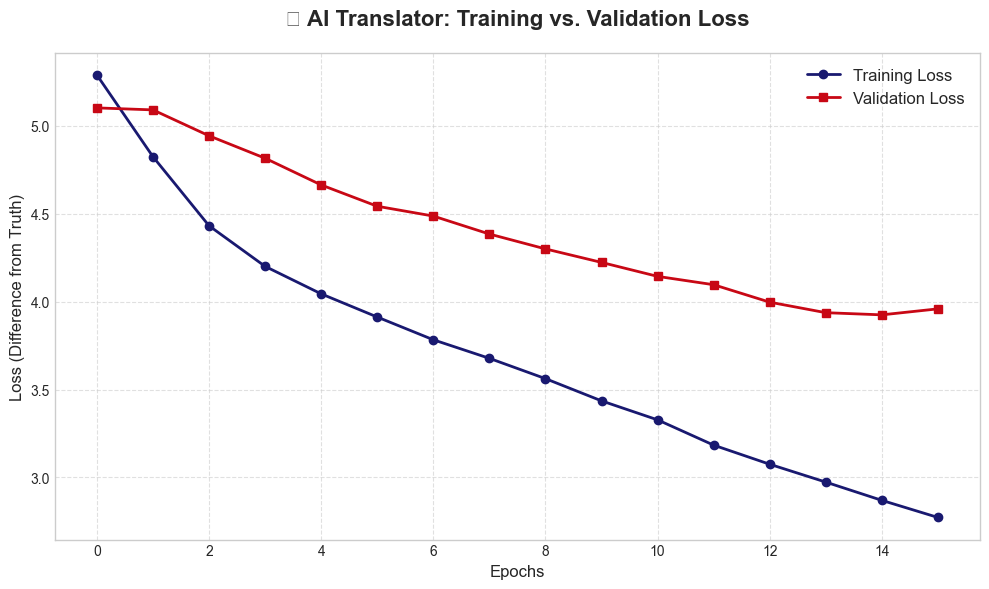

In [42]:
import matplotlib.pyplot as plt

# 1. Set the style to look professional
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid') # A clean look

# 2. Plot the Training Loss (The "Blue" line)
plt.plot(train_losses, label='Training Loss', color='#191970', linewidth=2, marker='o')

# 3. Plot the Validation Loss (The "Red" line)
plt.plot(valid_losses, label='Validation Loss', color='#C80815', linewidth=2, marker='s')

# 4. Add Labels and Title
plt.title('🌍 AI Translator: Training vs. Validation Loss', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Difference from Truth)', fontsize=12)

# 5. Add Legend and Grid
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Show the plot
plt.tight_layout()
plt.show()

In [43]:
import torch.nn.functional as F

def generate_translation(src_sentence, model=model, src_vocab=vocab_transform['de'], trg_vocab=vocab_transform['en'], max_len=50):
    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():
        src_tensor = text_transform[SRC_LANGUAGE](src_sentence).view(-1, 1).to(device)

        # Pass the source tensor through the encoder
        hidden, cell = model.encoder(src_tensor)

        # Create a tensor to store the generated translation
        # get_stoi() maps tokens to indices
        trg_indexes = [trg_vocab.get_stoi()['<bos>']]  # Start with <bos> token

        # Convert the initial token to a PyTorch tensor
        trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(1)  # Add batch dimension

        # Move the tensor to the same device as the model
        trg_tensor = trg_tensor.to(model.device)


        # Generate the translation
        for _ in range(max_len):

            # Pass the target tensor and the previous hidden and cell states through the decoder
            output, hidden, cell = model.decoder(trg_tensor[-1], hidden, cell)

            # Get the predicted next token
            pred_token = output.argmax(1)[-1].item()

            # Append the predicted token to the translation
            trg_indexes.append(pred_token)


            # If the predicted token is the <eos> token, stop generating
            if pred_token == trg_vocab.get_stoi()['<eos>']:
                break

            # Convert the predicted token to a PyTorch tensor
            trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(1)  # Add batch dimension

            # Move the tensor to the same device as the model
            trg_tensor = trg_tensor.to(model.device)

        # Convert the generated tokens to text
        # get_itos() maps indices to tokens
        trg_tokens = [trg_vocab.get_itos()[i] for i in trg_indexes]

        # Remove the <sos> and <eos> from the translation
        if trg_tokens[0] == '<bos>':
            trg_tokens = trg_tokens[1:]
        if trg_tokens[-1] == '<eos>':
            trg_tokens = trg_tokens[:-1]

        # Return the translation list as a string

        translation = " ".join(trg_tokens)

        return translation

In [ ]:


# Actual translation: Asian man sweeping the walkway.
src_sentence = 'Ein asiatischer Mann kehrt den Gehweg.'


generated_translation = generate_translation(src_sentence=src_sentence, model=model, src_vocab=vocab_transform['de'], trg_vocab=vocab_transform['en'], max_len=12)
print(generated_translation)


An Asian man walking down a street .


In [45]:
def calculate_bleu_score(generated_translation, reference_translations):
    # Convert the generated translations and reference translations into the expected format for sentence_bleu
    references = [reference.split() for reference in reference_translations]
    hypothesis = generated_translation.split()

    # Calculate the BLEU score
    bleu_score = sentence_bleu(references, hypothesis)

    return bleu_score

In [ ]:
# Skip the current batch to get fresh sentences
try:
    # We call next() twice to jump further into the dataset
    next(iter(valid_dataloader))
    src, trg = next(iter(valid_dataloader))
except StopIteration:
    # If we reached the end, restart
    valid_iterator = iter(valid_dataloader)
    src, trg = next(valid_iterator)

src, trg = src.to(device), trg.to(device)

print(f"{'GERMAN SOURCE':<40} | {'REAL ENGLISH':<40} | {'MODEL PREDICTION'}")
print("-" * 120)

# Loop through 5 sentences
for i in range(15,20):
    src_indices = src[:, i].tolist()
    trg_indices = trg[:, i].tolist()
    
    # Clean up tokens
    src_sent = " ".join([vocab_transform['de'].get_itos()[idx] for idx in src_indices if idx not in [0, 1, 2]])
    trg_sent = " ".join([vocab_transform['en'].get_itos()[idx] for idx in trg_indices if idx not in [0, 1, 2]])

    prediction = generate_translation(src_sent, model, vocab_transform['de'], vocab_transform['en'])
    
    print(f"{src_sent[:40]:<40} | {trg_sent[:40]:<40} | {prediction}")

GERMAN SOURCE                            | REAL ENGLISH                             | MODEL PREDICTION
------------------------------------------------------------------------------------------------------------------------
Drei Hunde spielen im Wasser . <eos>     | Three dogs are playing in the water . <e | Three dogs are playing in the water with water .
Eine Gruppe von Menschen läuft . <eos>   | A group of people are running . <eos>    | A group of people are walking together .
Bauern betreiben tagsüber ihre . <eos>   | Farmers are performing their during the  | An couple couple is to to the .
Drei kleine Hunde schnüffeln an etwas .  | Three small dogs at something . <eos>    | Three small dogs are to to the the .
Zwei Mädchen gehen eine Straße entlang . | Two girls walking down the street . <eos | Two girls walk down a street street with trees .


In [71]:
%pip install datasets


   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 2.8 MB/s  0:00:00
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   -- ------------------------------------- 1.6/27.5 MB 7.6 MB/s eta 0:00:04
   ---- ----------------------------------- 3.4/27.5 MB 7.7 MB/s eta 0:00:04
   ------ --------------------------------- 4.7/27.5 MB 7.9 MB/s eta 0:00:03
   --------- ------------------------------ 6.8/27.5 MB 7.6 MB/s eta 0:00:03
   ----------- ---------------------------- 8.1/27.5 MB 7.3 MB/s eta 0:00:03
   ------------- -------------------------- 9.2/27.5 MB 7.1 MB/s eta 0:00:03
   -------------- ------------------------- 10.2/27.5 MB 6.9 MB/s eta 0:00:03
   ---------------- ----------------------- 11.3/27.5 MB 6.4 MB/s eta 0:00:03
   ----------------- ---------------------- 12.3/27.5 MB 6.2 MB/s eta 0:00:03
   ------------------ --------------------- 12.8/27.5 MB 6.1 MB/s eta 0:00:03
   ----

In [ ]:
from datasets import load_dataset

# 1. Re-load the data 
print("Loading raw data for BLEU evaluation...")
raw_data = load_dataset("bentrevett/multi30k")

#run the BLEU calculation again
final_score = calculate_final_bleu(
    model=model, 
    dataset=raw_data['validation'], 
    vocab_de=vocab_transform['de'], 
    vocab_en=vocab_transform['en']
)

print(f"\n✅ Final Model BLEU Score: {final_score * 100:.2f}")

Loading raw data for BLEU evaluation...


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

...

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Calculating BLEU Score on Validation Set...


100%|██████████| 1014/1014 [46:03<00:00,  2.73s/it]   



✅ Final Model BLEU Score: 11.71


In [ ]:
model.eval()

# 1. Get a batch from the dataloader
# Ensure the batch is on the correct device
src, trg = next(iter(valid_dataloader))
src, trg = src.to(device), trg.to(device)

print(f"{'GERMAN SOURCE':<40} | {'REAL ENGLISH':<40} | {'MODEL PREDICTION'}")
print("-" * 120)

# 2. Loop through the first 5 sentences in this batch
for i in range(5):
    # CHANGED: Added .get_itos() instead of .itos
    src_indices = src[:, i].tolist()
    trg_indices = trg[:, i].tolist()
    
    src_sent = " ".join([vocab_transform['de'].get_itos()[idx] for idx in src_indices if idx not in [3 15,]])
    trg_sent = " ".join([vocab_transform['en'].get_itos()[idx] for idx in trg_indices if idx not in [0, 1, 2]])

    # 3. Call your translation function
    prediction = generate_translation(src_sent, model, vocab_transform['de'], vocab_transform['en'])
    
    # 4. Print formatted results
    print(f"{src_sent[:40]:<40} | {trg_sent[:40]:<40} | {prediction}")

GERMAN SOURCE                            | REAL ENGLISH                             | MODEL PREDICTION
------------------------------------------------------------------------------------------------------------------------
<eos>                                    | <eos>                                    | Some workers are on the . .
Ein Mann boxt <eos>                      | A man practices boxing <eos>             | A man is a a . .
Bauarbeiter stehen auf einer Maschine <e | Construction workers standing on top of  | Construction workers working on a on a a . .
Kinder fahren in einem Kettenkarussell < | Kids are riding a swinging carnival ride | Children are in a field with a . .
Zwei Menschen überqueren eine Straße . < | Two people walking across a street . <eo | Two people are walking down a street street .
